In [1]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d
import pandas as pd
import math
import random

In [10]:
# Define Euler Solver in Python
def euler_solver_3d(f1, f2, f3, t0, tf, x10, x20, x30, h):
    '''
    f1: EDO f(x1, x2, x3); f2: EDO g(x1, x2, x3); f3: EDO h(x1, x2, x3)
    t0: Tiempo inicial; tf: Tiempo final
    x10, x20 y x30: Condiciones iniciales dimensiones 1, 2 y 3
    h: Timestep 
    '''

    # Define steps
    steps = int((tf-t0)/h)

    # Initialize variables & lists
    x1 = x10
    x2 = x20
    x3 = x30
    t = t0

    t_list = [t]
    x1_list = [x1]
    x2_list = [x2]
    x3_list = [x3]


    # For loop
    for i in range(steps):

        x1_old = x1
        x2_old = x2
        x3_old = x3

        x1 = x1_old + h*f1(t, x1_old, x2_old, x3_old)
        x2 = x2_old + h*f2(t, x1_old, x2_old, x3_old)
        x3 = x3_old + h*f3(t, x1_old, x2_old, x3_old)
        t = t + h

        t_list.append(t)
        x1_list.append(x1)
        x2_list.append(x2)
        x3_list.append(x3)

    return np.array(t_list), np.array(x1_list), np.array(x2_list), np.array(x3_list)

In [13]:
import numpy as np

# Define RK4 Solver in Python
def rk4_solver_3d(f1, f2, f3, t0, tf, x10, x20, x30, h):
    '''
    f1: EDO f(x1, x2, x3)
    f2: EDO g(x1, x2, x3)
    f3: EDO h(x1, x2, x3)

    t0: Tiempo inicial
    tf: Tiempo final

    x10, x20, x30: Condiciones iniciales

    h: Timestep
    '''

    # Define steps
    steps = int((tf - t0) / h)

    # Initialize variables
    x1 = x10
    x2 = x20
    x3 = x30
    t = t0

    # Store results
    t_list = [t]
    x1_list = [x1]
    x2_list = [x2]
    x3_list = [x3]

    # Time loop
    for i in range(steps):

        # k1
        k11 = f1(t, x1, x2, x3)
        k12 = f2(t, x1, x2, x3)
        k13 = f3(t, x1, x2, x3)

        # k2
        k21 = f1(
            t + h/2,
            x1 + h*k11/2,
            x2 + h*k12/2,
            x3 + h*k13/2
        )

        k22 = f2(
            t + h/2,
            x1 + h*k11/2,
            x2 + h*k12/2,
            x3 + h*k13/2
        )

        k23 = f3(
            t + h/2,
            x1 + h*k11/2,
            x2 + h*k12/2,
            x3 + h*k13/2
        )

        # k3
        k31 = f1(
            t + h/2,
            x1 + h*k21/2,
            x2 + h*k22/2,
            x3 + h*k23/2
        )

        k32 = f2(
            t + h/2,
            x1 + h*k21/2,
            x2 + h*k22/2,
            x3 + h*k23/2
        )

        k33 = f3(
            t + h/2,
            x1 + h*k21/2,
            x2 + h*k22/2,
            x3 + h*k23/2
        )

        # k4
        k41 = f1(
            t + h,
            x1 + h*k31,
            x2 + h*k32,
            x3 + h*k33
        )

        k42 = f2(
            t + h,
            x1 + h*k31,
            x2 + h*k32,
            x3 + h*k33
        )

        k43 = f3(
            t + h,
            x1 + h*k31,
            x2 + h*k32,
            x3 + h*k33
        )

        # Update solution
        x1 += (h/6)*(k11 + 2*k21 + 2*k31 + k41)
        x2 += (h/6)*(k12 + 2*k22 + 2*k32 + k42)
        x3 += (h/6)*(k13 + 2*k23 + 2*k33 + k43)

        t += h

        # Store results
        t_list.append(t)
        x1_list.append(x1)
        x2_list.append(x2)
        x3_list.append(x3)

    return (
        np.array(t_list),
        np.array(x1_list),
        np.array(x2_list),
        np.array(x3_list)
    )

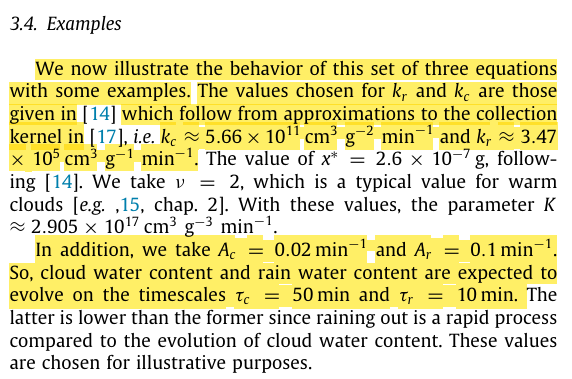

In [16]:
# Define parameter values
AC = 0.02 # min-1
AR = 0.1 # min-1
KR = 3.47e5 # cm3 g-1 min-1
KC = 5.66e11 # cm3 g-2 min-1
K = 2.905e17 # cm3 g-3 min-1

In [7]:
def dLcdt(t, Lc, Lr, Nd):
    bc = K * Nd**(-2)
    return AC*Lc - bc*Lc**4 - KR*Lc*Lr

def dLrdt(t, Lc, Lr, Nd):
    bc = K * Nd**(-2)
    return -AR*Lr + bc*Lc**4 + KR*Lc*Lr

def dNddt(t, Lc, Lr, Nd):
    return AC*(N0 - Nd) - (4/3)*KC*Lc**2 - KR*Lr*Nd

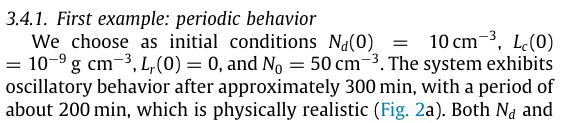

In [8]:
# Initial codnitions (test)
ND0 = 10 # cm-3
LC0 = 10e-9 # cm-3
LR0 = 0
N0 = 50 # cm-3

In [17]:
#
H = 0.001

t, lc, lr, nd = euler_solver_3d(dLcdt, dLrdt, dNddt, 
                                0, 500, 
                                LC0, LR0, N0, 
                                H)

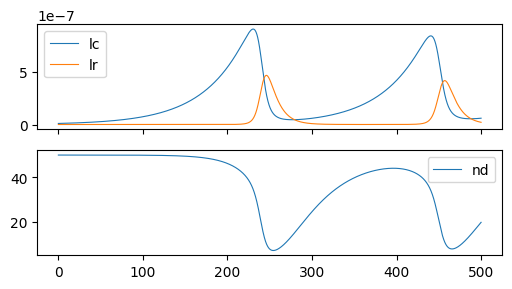

In [27]:
fig, ax = plt.subplots(2, 1, figsize=(6, 3), sharex = True)

ax[0].plot(t, lc, lw = 0.8, label='lc')
ax[0].plot(t, lr, lw = 0.8, label='lr')

ax[1].plot(t, nd, lw = 0.8, label='nd')

ax[0].legend()
ax[1].legend()

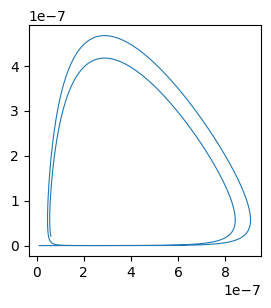

In [28]:
fig, ax = plt.subplots(figsize=(3, 3), sharex = True)

ax.plot(lc, lr, lw = 0.8, label='lc')